# NOTE: Used to make plots for reports, updated scripts now saved in 
`USOS_Shared/Compare_UDAQ_MobileLab/scripts/ozone_comparison_scripts.py`

---

# Time Series comparison of ozone concentration

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

dirpath = '/uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_shared/'

mpl.rcParams['xtick.labelsize'] = 15
mpl.rcParams['ytick.labelsize'] = 15
mpl.rcParams['legend.fontsize'] = 16
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['axes.titlesize'] = 28
mpl.rcParams['axes.xmargin'] = 0

# Set the font family to 'serif'
mpl.rcParams['font.family'] = 'serif'
# Specify preferred serif font (Computer Modern Roman is 'cmr10')
mpl.rcParams['font.serif'] = 'Lato' 
# Optionally, configure mathtext to use Computer Modern fonts as well
mpl.rcParams['mathtext.fontset'] = 'cm'
# Ensure minus signs are rendered correctly with CM fonts
mpl.rcParams['axes.unicode_minus'] = False

hour_range = np.arange(0,24,1)

mobilelab_hourly_o3_filepath = dirpath + 'USOS_Campaign_analysis/resaved_data/ozone_hourly.csv'
mobilelab_o3 = pd.read_csv(mobilelab_hourly_o3_filepath,index_col = 'time_local', parse_dates=True)

udaq_o3_filepath = dirpath + 'Hawthorne_data/data/hawthorne_udaq_o3_2024_timezone_updated.csv'
df_udaq_o3_load = pd.read_csv(udaq_o3_filepath, index_col = 'time_local', parse_dates=True)
#display(df_udaq_o3_load)

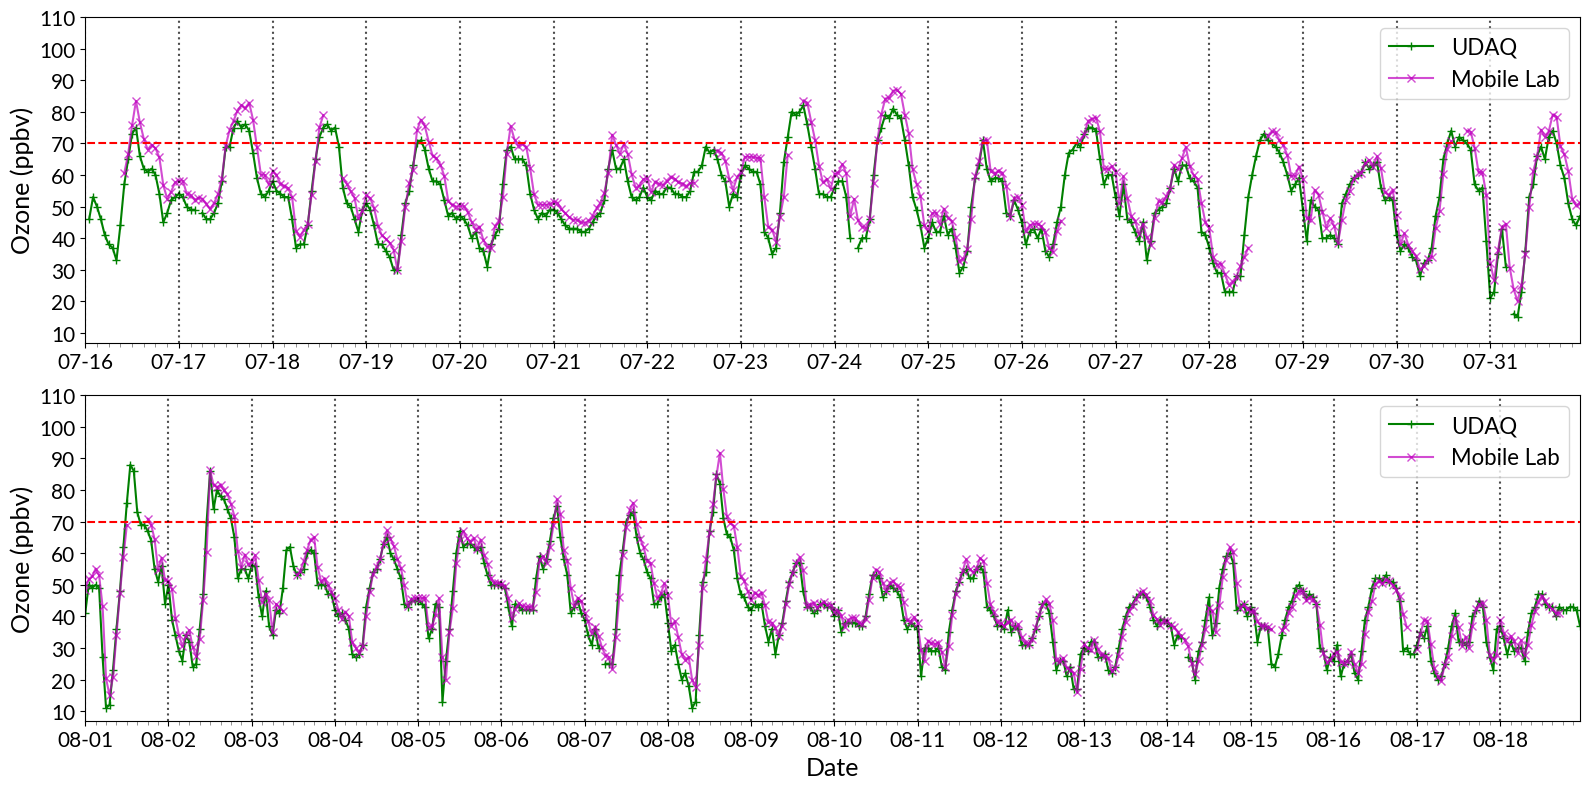

In [ ]:
#time series with subplots and uncertainty
fig, (ax1, ax2) = plt.subplots(2,1, figsize = (16,8), tight_layout=True)
ax1.plot(df_udaq_o3_load.index, df_udaq_o3_load['UDAQ O3'], linestyle = 'solid', color = 'g', marker = '+', label = 'UDAQ')
ax1.plot(mobilelab_o3.index, mobilelab_o3['Mobile Lab O3'], linestyle = 'solid', color='m', marker='x',label='Mobile Lab', alpha = 0.7)

#Add 70 ppb horizontal line
ax1.hlines(y=70, xmin = df_udaq_o3_load.index[0], xmax = df_udaq_o3_load.index[len(df_udaq_o3_load.index)-1], linestyle = 'dashed', color = 'r')
#Mark midnight for every day
midnight_vals = []
for midnight_idx in range(0,len(df_udaq_o3_load.index),24):
    midnight_vals.append(df_udaq_o3_load.index[midnight_idx])
for day_pos in midnight_vals:
    ax1.axvline(day_pos, color = 'black', linestyle = 'dotted', alpha = 0.7)

#Set x ticks
ax1.xaxis.set_major_locator(mdates.DayLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
# Minor ticks: every 3 hours
ax1.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 3, 6, 9, 12, 15, 18, 21]))
# Rotate and format tick labels
ax1.tick_params(axis='x', which='major')
ax1.tick_params(axis='x', which='minor', length=3, color='gray')
#ax.grid(True, which='both')
ax1.set_yticks(np.arange(10,120,10))
ax1.set_ylabel('Ozone (ppbv)')
#ax1.set_xlabel('Date')
ax1.margins(x=0)

ax1.legend(loc = 'upper right')
ax1.set_xlim([pd.to_datetime('2024-07-16 00:00:00'), pd.to_datetime('2024-07-31 23:00:00')])

ax2.plot(mobilelab_o3.index, df_udaq_o3_load['UDAQ O3'], linestyle = 'solid', color = 'g', marker = '+', label = 'UDAQ')
ax2.plot(mobilelab_o3.index, mobilelab_o3['Mobile Lab O3'], linestyle = 'solid', color='m', marker='x',label='Mobile Lab', alpha = 0.7)

ax2.hlines(y=70, xmin = df_udaq_o3_load.index[0], xmax = df_udaq_o3_load.index[len(df_udaq_o3_load.index)-1], linestyle = 'dashed', color = 'r')
#Mark midnight for every day
midnight_vals = []
for midnight_idx in range(0,len(df_udaq_o3_load.index),24):
    midnight_vals.append(df_udaq_o3_load.index[midnight_idx])
for day_pos in midnight_vals:
    ax2.axvline(day_pos, color = 'black', linestyle = 'dotted', alpha = 0.7)
#Set x ticks
ax2.xaxis.set_major_locator(mdates.DayLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
# Minor ticks: every 3 hours
ax2.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 3, 6, 9, 12, 15, 18, 21]))
# Rotate and format tick labels
ax2.tick_params(axis='x', which='major')
ax2.tick_params(axis='x', which='minor', length=3, color='gray')
ax2.set_yticks(np.arange(10,120,10))
ax2.set_ylabel('Ozone (ppbv)')
ax2.set_xlabel('Date')
ax2.margins(x=0)
ax2.set_xlim([pd.to_datetime('2024-08-01 00:00:00'), pd.to_datetime('2024-08-18 23:00:00')])

ax2.legend(loc = 'upper right')
# handles, labels = ax2.gca().get_legend_handles_labels()
# order = [0,1]
# ax1.legend([handles[idx] for idx in order],[labels[idx] for idx in order])
# handles, labels = plt.gca().get_legend_handles_labels()
# order = [0,1]
# plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order])

#plt.suptitle('Ozone Comparison Between UDAQ and Mobile Lab Measurements (July 2024)')
plt.savefig(dirpath + '/UDAQ_reports/q1_report/plots/hawthorne_udaq_mobilelab_o3_comparison_july_aug_no_uncertainties.png', dpi =300)
plt.show()


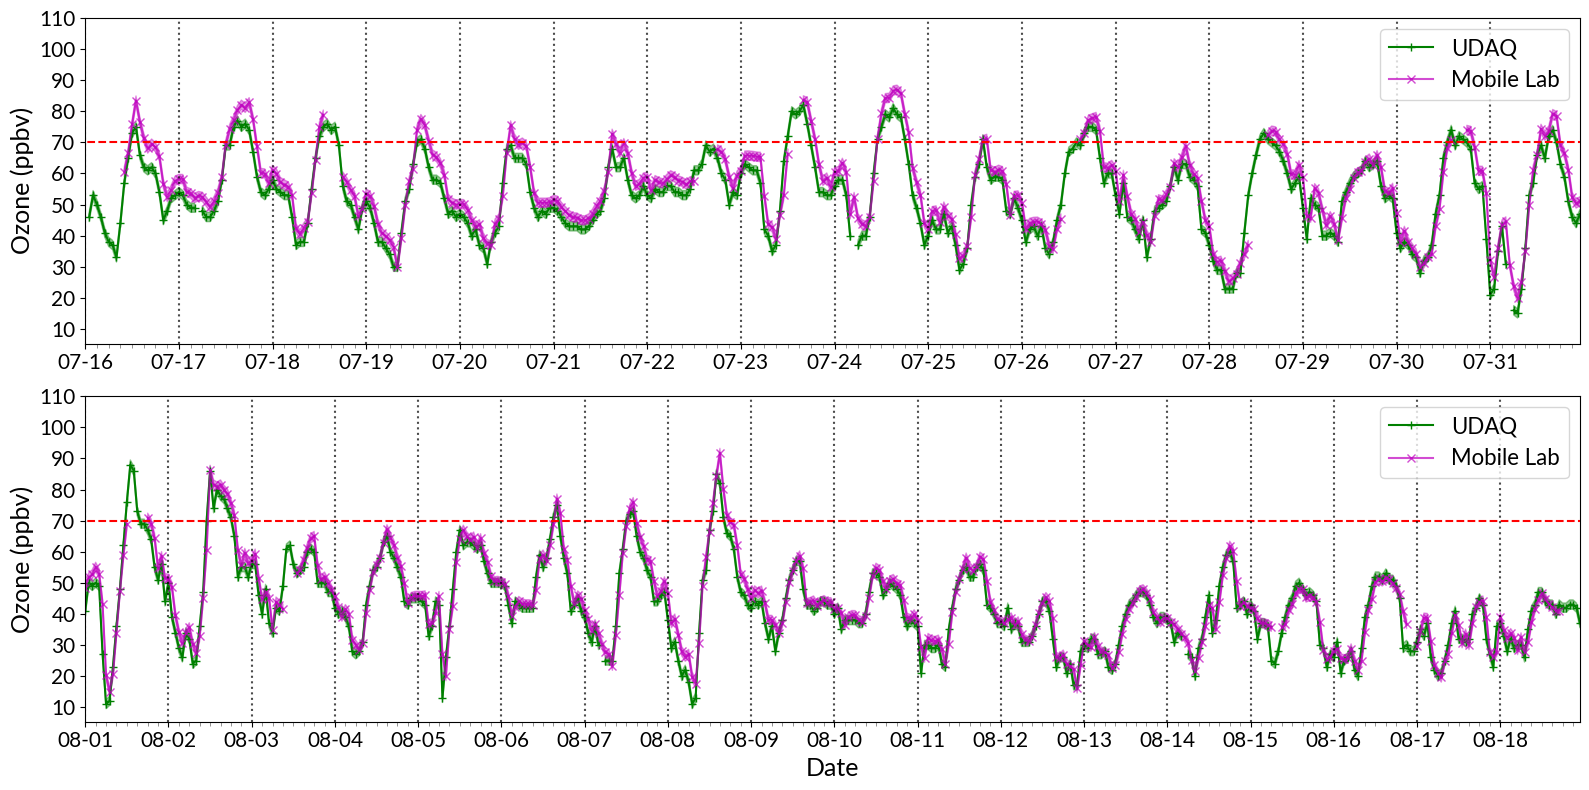

In [4]:
#time series with subplots and uncertainty
fig, (ax1, ax2) = plt.subplots(2,1, figsize = (16,8), tight_layout=True)
ax1.plot(df_udaq_o3_load.index, df_udaq_o3_load['UDAQ O3'], linestyle = 'solid', color = 'g', marker = '+', label = 'UDAQ')
ax1.plot(mobilelab_o3.index, mobilelab_o3['Mobile Lab O3'], linestyle = 'solid', color='m', marker='x',label='Mobile Lab', alpha = 0.7)

udaq_uncertainty_upper = df_udaq_o3_load['UDAQ O3']+1.5
udaq_uncertainty_lower = df_udaq_o3_load['UDAQ O3']-1.5
ml_uncertainty_upper = mobilelab_o3['Mobile Lab O3']+1.5
ml_uncertainty_lower = mobilelab_o3['Mobile Lab O3']-1.5

ax1.fill_between(df_udaq_o3_load.index, y1 = udaq_uncertainty_lower, y2 = udaq_uncertainty_upper,  color = 'g', alpha = 0.4)
ax1.fill_between(mobilelab_o3.index, y1 = ml_uncertainty_lower, y2 = ml_uncertainty_upper,color = 'm', alpha = 0.4)

#Add 70 ppb horizontal line
ax1.hlines(y=70, xmin = df_udaq_o3_load.index[0], xmax = df_udaq_o3_load.index[len(df_udaq_o3_load.index)-1], linestyle = 'dashed', color = 'r')
#Mark midnight for every day
midnight_vals = []
for midnight_idx in range(0,len(df_udaq_o3_load.index),24):
    midnight_vals.append(df_udaq_o3_load.index[midnight_idx])
for day_pos in midnight_vals:
    ax1.axvline(day_pos, color = 'black', linestyle = 'dotted', alpha = 0.7)

#Set x ticks
ax1.xaxis.set_major_locator(mdates.DayLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
# Minor ticks: every 3 hours
ax1.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 3, 6, 9, 12, 15, 18, 21]))
# Rotate and format tick labels
ax1.tick_params(axis='x', which='major')
ax1.tick_params(axis='x', which='minor', length=3, color='gray')
#ax.grid(True, which='both')
ax1.set_yticks(np.arange(10,120,10))
ax1.set_ylabel('Ozone (ppbv)')
#ax1.set_xlabel('Date')
ax1.margins(x=0)

ax1.legend(loc = 'upper right')
# handles, labels = ax1.gca().get_legend_handles_labels()
# order = [0,1]
# ax1.legend([handles[idx] for idx in order],[labels[idx] for idx in order])

ax1.set_xlim([pd.to_datetime('2024-07-16 00:00:00'), pd.to_datetime('2024-07-31 23:00:00')])

ax2.plot(mobilelab_o3.index, df_udaq_o3_load['UDAQ O3'], linestyle = 'solid', color = 'g', marker = '+', label = 'UDAQ')
ax2.plot(mobilelab_o3.index, mobilelab_o3['Mobile Lab O3'], linestyle = 'solid', color='m', marker='x',label='Mobile Lab', alpha = 0.7)

ax2.fill_between(df_udaq_o3_load.index, y1 = udaq_uncertainty_lower, y2 = udaq_uncertainty_upper,  color = 'g', alpha = 0.4)
ax2.fill_between(mobilelab_o3.index, y1 = ml_uncertainty_lower, y2 = ml_uncertainty_upper,color = 'm', alpha = 0.4)

#print(df_udaq_o3_load.index)
ax2.hlines(y=70, xmin = df_udaq_o3_load.index[0], xmax = df_udaq_o3_load.index[len(df_udaq_o3_load.index)-1], linestyle = 'dashed', color = 'r')
#Mark midnight for every day
midnight_vals = []
for midnight_idx in range(0,len(df_udaq_o3_load.index),24):
    midnight_vals.append(df_udaq_o3_load.index[midnight_idx])
for day_pos in midnight_vals:
    ax2.axvline(day_pos, color = 'black', linestyle = 'dotted', alpha = 0.7)
#Set x ticks
ax2.xaxis.set_major_locator(mdates.DayLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
# Minor ticks: every 3 hours
ax2.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 3, 6, 9, 12, 15, 18, 21]))
# Rotate and format tick labels
ax2.tick_params(axis='x', which='major')
ax2.tick_params(axis='x', which='minor', length=3, color='gray')
ax2.set_yticks(np.arange(10,120,10))
ax2.set_ylabel('Ozone (ppbv)')
ax2.set_xlabel('Date')
ax2.margins(x=0)
ax2.set_xlim([pd.to_datetime('2024-08-01 00:00:00'), pd.to_datetime('2024-08-18 23:00:00')])

ax2.legend(loc = 'upper right')
# handles, labels = ax2.gca().get_legend_handles_labels()
# order = [0,1]
# ax1.legend([handles[idx] for idx in order],[labels[idx] for idx in order])
# handles, labels = plt.gca().get_legend_handles_labels()
# order = [0,1]
# plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order])

#plt.suptitle('Ozone Comparison Between UDAQ and Mobile Lab Measurements (July 2024)')
# plt.savefig(dirpath + '/Compare_UDAQ_MobileLab/plots/hawthorne_udaq_mobilelab_o3_comparison_july.png', dpi =300)
plt.savefig(dirpath + '/UDAQ_reports/q1_report/plots/hawthorne_udaq_mobilelab_o3_comparison_july_aug_uncertainties.png', dpi =300)
plt.show()



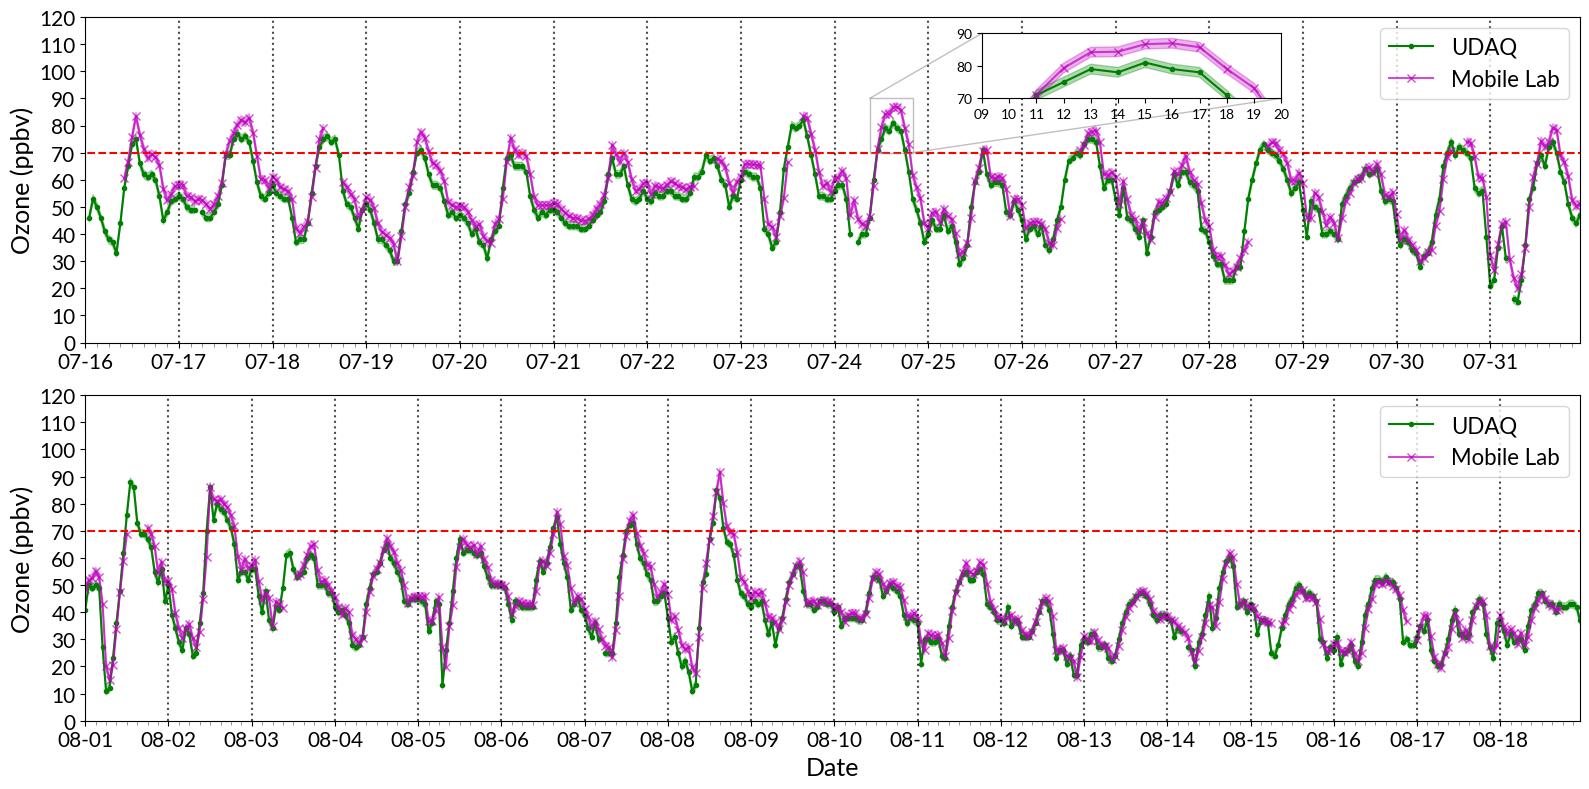

In [80]:
#time series with subplots and uncertainty
fig, (ax1, ax2) = plt.subplots(2,1, figsize = (16,8), tight_layout=True)
ax1.plot(df_udaq_o3_load.index, df_udaq_o3_load['UDAQ O3'], linestyle = 'solid', color = 'g', marker = '.', label = 'UDAQ')
ax1.plot(mobilelab_o3.index, mobilelab_o3['Mobile Lab O3'], linestyle = 'solid', color='m', marker='x',label='Mobile Lab', alpha = 0.7)

udaq_uncertainty_upper = df_udaq_o3_load['UDAQ O3']+1.5
udaq_uncertainty_lower = df_udaq_o3_load['UDAQ O3']-1.5
ml_uncertainty_upper = mobilelab_o3['Mobile Lab O3']+1.5
ml_uncertainty_lower = mobilelab_o3['Mobile Lab O3']-1.5

ax1.fill_between(df_udaq_o3_load.index, y1 = udaq_uncertainty_lower, y2 = udaq_uncertainty_upper,  color = 'g', alpha = 0.3)
ax1.fill_between(mobilelab_o3.index, y1 = ml_uncertainty_lower, y2 = ml_uncertainty_upper,color = 'm', alpha = 0.3)

#Add 70 ppb horizontal line
ax1.hlines(y=70, xmin = df_udaq_o3_load.index[0], xmax = df_udaq_o3_load.index[len(df_udaq_o3_load.index)-1], linestyle = 'dashed', color = 'r')
#Mark midnight for every day
midnight_vals = []
for midnight_idx in range(0,len(df_udaq_o3_load.index),24):
    midnight_vals.append(df_udaq_o3_load.index[midnight_idx])
for day_pos in midnight_vals:
    ax1.axvline(day_pos, color = 'black', linestyle = 'dotted', alpha = 0.7)


axin = ax1.inset_axes([0.6, 0.75, 0.2, 0.2])
axin.set_xlim([pd.to_datetime('2024-07-24 09:00:00'), pd.to_datetime('2024-07-24 20:00:00')])
axin.set_ylim(70, 90)
axin.plot(df_udaq_o3_load.index, df_udaq_o3_load['UDAQ O3'], linestyle = 'solid', color = 'g', marker = '.', label = 'UDAQ')
axin.plot(mobilelab_o3.index, mobilelab_o3['Mobile Lab O3'], linestyle = 'solid', color='m', marker='x',label='Mobile Lab', alpha = 0.7)
axin.fill_between(df_udaq_o3_load.index, y1 = udaq_uncertainty_lower, y2 = udaq_uncertainty_upper,  color = 'g', alpha = 0.3)
axin.fill_between(mobilelab_o3.index, y1 = ml_uncertainty_lower, y2 = ml_uncertainty_upper,color = 'm', alpha = 0.3)
axin.tick_params(axis='x', labelsize=10)
axin.tick_params(axis='y', labelsize=10)
axin.xaxis.set_major_locator(mdates.HourLocator())
axin.xaxis.set_major_formatter(mdates.DateFormatter('%H'))

ax1.indicate_inset_zoom(axin)

#Set x ticks
ax1.xaxis.set_major_locator(mdates.DayLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
# Minor ticks: every 3 hours
ax1.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 3, 6, 9, 12, 15, 18, 21]))
# Rotate and format tick labels
ax1.tick_params(axis='x', which='major')
ax1.tick_params(axis='x', which='minor', length=3, color='gray')
#ax.grid(True, which='both')
ax1.set_yticks(np.arange(0,130,10))
ax1.set_ylabel('Ozone (ppbv)')
#ax1.set_xlabel('Date')
ax1.margins(x=0)
ax1.set_ylim(0,120)

ax1.legend(loc = 'upper right')
# handles, labels = ax1.gca().get_legend_handles_labels()
# order = [0,1]
# ax1.legend([handles[idx] for idx in order],[labels[idx] for idx in order])

ax1.set_xlim([pd.to_datetime('2024-07-16 00:00:00'), pd.to_datetime('2024-07-31 23:00:00')])

ax2.plot(mobilelab_o3.index, df_udaq_o3_load['UDAQ O3'], linestyle = 'solid', color = 'g', marker = '.', label = 'UDAQ')
ax2.plot(mobilelab_o3.index, mobilelab_o3['Mobile Lab O3'], linestyle = 'solid', color='m', marker='x',label='Mobile Lab', alpha = 0.7)

ax2.fill_between(df_udaq_o3_load.index, y1 = udaq_uncertainty_lower, y2 = udaq_uncertainty_upper,  color = 'g', alpha = 0.3)
ax2.fill_between(mobilelab_o3.index, y1 = ml_uncertainty_lower, y2 = ml_uncertainty_upper, color = 'm', alpha = 0.3)

#print(df_udaq_o3_load.index)
ax2.hlines(y=70, xmin = df_udaq_o3_load.index[0], xmax = df_udaq_o3_load.index[len(df_udaq_o3_load.index)-1], linestyle = 'dashed', color = 'r')
#Mark midnight for every day
midnight_vals = []
for midnight_idx in range(0,len(df_udaq_o3_load.index),24):
    midnight_vals.append(df_udaq_o3_load.index[midnight_idx])
for day_pos in midnight_vals:
    ax2.axvline(day_pos, color = 'black', linestyle = 'dotted', alpha = 0.7)
#Set x ticks
ax2.xaxis.set_major_locator(mdates.DayLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
# Minor ticks: every 3 hours
ax2.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 3, 6, 9, 12, 15, 18, 21]))
# Rotate and format tick labels
ax2.tick_params(axis='x', which='major')
ax2.tick_params(axis='x', which='minor', length=3, color='gray')
ax2.set_yticks(np.arange(0,130,10))
ax2.set_ylabel('Ozone (ppbv)')
ax2.set_xlabel('Date')
ax2.margins(x=0)
ax2.set_xlim([pd.to_datetime('2024-08-01 00:00:00'), pd.to_datetime('2024-08-18 23:00:00')])
ax2.set_ylim(0,120)

ax2.legend(loc = 'upper right')
# handles, labels = ax2.gca().get_legend_handles_labels()
# order = [0,1]
# ax1.legend([handles[idx] for idx in order],[labels[idx] for idx in order])
# handles, labels = plt.gca().get_legend_handles_labels()
# order = [0,1]
# plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order])

#plt.suptitle('Ozone Comparison Between UDAQ and Mobile Lab Measurements (July 2024)')
plt.savefig(dirpath + '/UDAQ_reports/q1_report/plots/hawthorne_udaq_mobilelab_o3_comparison_july_aug_with_inset_and_uncertainties.png', dpi =300)
plt.show()



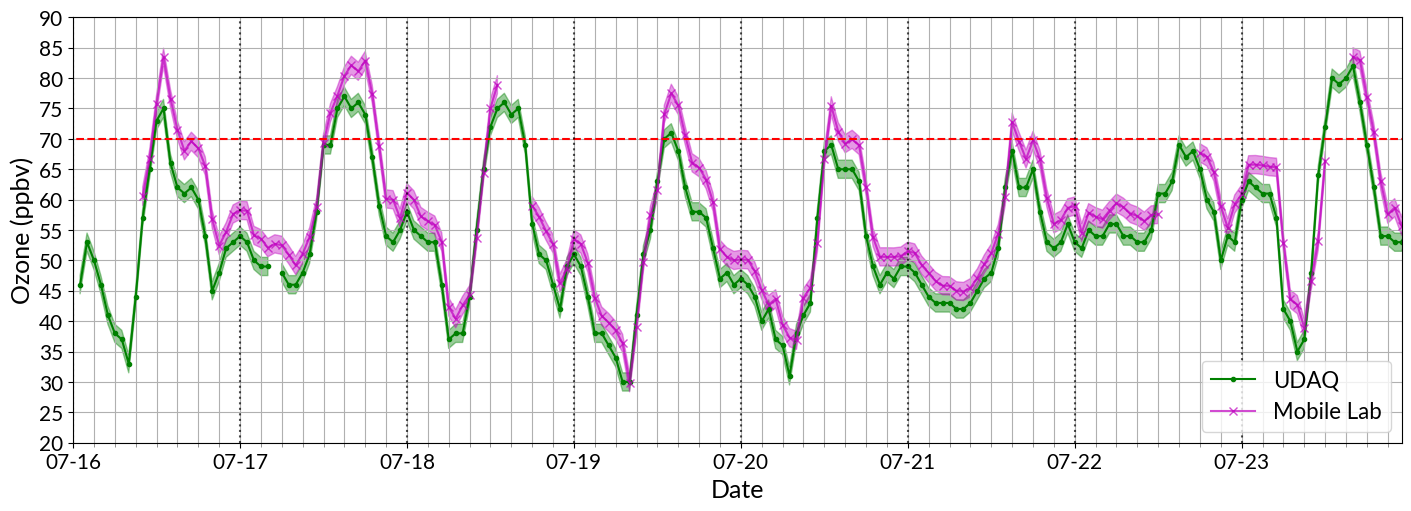

In [6]:
#First week time series
fig, ax = plt.subplots(figsize = (14,5), constrained_layout=True)
ax.plot(mobilelab_o3.index, df_udaq_o3_load['UDAQ O3'], linestyle = 'solid', color = 'g', marker = '.', label = 'UDAQ')
ax.plot(mobilelab_o3.index, mobilelab_o3['Mobile Lab O3'], linestyle = 'solid', color='m', marker='x',label='Mobile Lab', alpha = 0.7)

udaq_uncertainty_upper = df_udaq_o3_load['UDAQ O3']+1.5
udaq_uncertainty_lower = df_udaq_o3_load['UDAQ O3']-1.5
ml_uncertainty_upper = mobilelab_o3['Mobile Lab O3']+1.5
ml_uncertainty_lower = mobilelab_o3['Mobile Lab O3']-1.5

ax.fill_between(df_udaq_o3_load.index, y1 = udaq_uncertainty_lower, y2 = udaq_uncertainty_upper,  color = 'g', alpha = 0.4)
ax.fill_between(mobilelab_o3.index, y1 = ml_uncertainty_lower, y2 = ml_uncertainty_upper,color = 'm', alpha = 0.4)

ax.hlines(y=70, xmin = df_udaq_o3_load.index[0], xmax = df_udaq_o3_load.index[len(df_udaq_o3_load.index)-1], linestyle = 'dashed', color = 'r')
#Mark midnight for every day
midnight_vals = []
for midnight_idx in range(0,len(df_udaq_o3_load.index),24):
    midnight_vals.append(df_udaq_o3_load.index[midnight_idx])
for day_pos in midnight_vals:
    ax.axvline(day_pos, color = 'black', linestyle = 'dotted', alpha = 0.7)
#Set x ticks
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
# Minor ticks: every 3 hours
ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 3, 6, 9, 12, 15, 18, 21]))
# Rotate and format tick labels
ax.tick_params(axis='x', which='major')
ax.tick_params(axis='x', which='minor', length=3, color='gray')
#ax.grid(True, which='both')
plt.ylim([20, 90])
plt.yticks(np.arange(20,95,5))
plt.ylabel('Ozone (ppbv)')
plt.xlabel('Date')
plt.margins(x=0)
plt.grid(which = 'both', axis = 'both')

ax.set_xlim([pd.to_datetime('2024-07-16 00:00:00'), pd.to_datetime('2024-07-23 23:00:00')])

handles, labels = plt.gca().get_legend_handles_labels()
order = [0,1]
plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order], loc = 'lower right')

#plt.title('Ozone Comparison Between UDAQ and Mobile Lab Measurements (July 2024)')
plt.savefig(dirpath + '/UDAQ_reports/q1_report/plots/hawthorne_udaq_mobilelab_o3_comparison_first_week_with_grid_and_uncertainties.png', dpi =300)
plt.show()



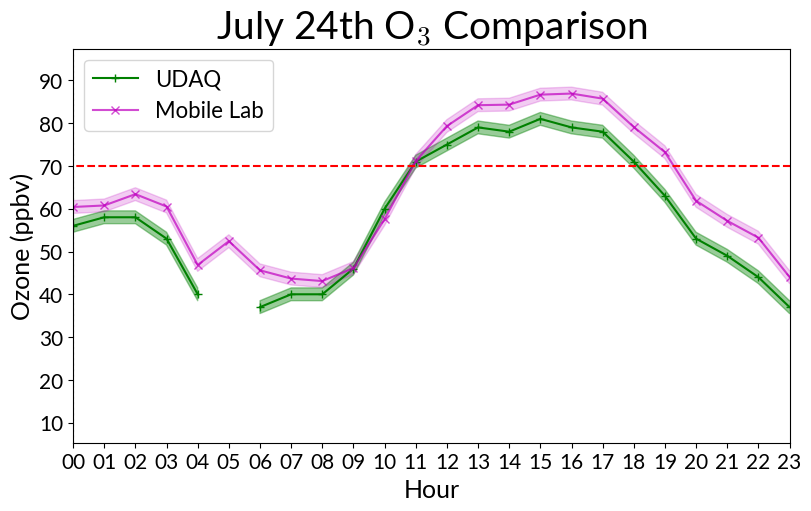

In [7]:

fig, ax = plt.subplots(figsize = (8,5), constrained_layout=True)
ax.plot(mobilelab_o3.index, df_udaq_o3_load['UDAQ O3'], linestyle = 'solid', color = 'g', marker = '+', label = 'UDAQ')
ax.plot(mobilelab_o3.index, mobilelab_o3['Mobile Lab O3'], linestyle = 'solid', color='m', marker='x',label='Mobile Lab', alpha = 0.7)

udaq_uncertainty_upper = df_udaq_o3_load['UDAQ O3']+1.5
udaq_uncertainty_lower = df_udaq_o3_load['UDAQ O3']-1.5
ml_uncertainty_upper = mobilelab_o3['Mobile Lab O3']+1.5
ml_uncertainty_lower = mobilelab_o3['Mobile Lab O3']-1.5

ax.fill_between(df_udaq_o3_load.index, y1 = udaq_uncertainty_lower, y2 = udaq_uncertainty_upper,  color = 'g', alpha = 0.4)
ax.fill_between(mobilelab_o3.index, y1 = ml_uncertainty_lower, y2 = ml_uncertainty_upper,color = 'm', alpha = 0.2)

#print(df_udaq_o3_load.index)
ax.hlines(y=70, xmin = df_udaq_o3_load.index[0], xmax = df_udaq_o3_load.index[len(df_udaq_o3_load.index)-1], linestyle = 'dashed', color = 'r')
#Mark midnight for every day
midnight_vals = []
for midnight_idx in range(0,len(df_udaq_o3_load.index),24):
    midnight_vals.append(df_udaq_o3_load.index[midnight_idx])
for day_pos in midnight_vals:
    ax.axvline(day_pos, color = 'black', linestyle = 'dotted', alpha = 0.7)

# ax.xaxis.set_major_locator(mdates.HourLocator())
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%H'))
# Minor ticks: every 3 hours
# ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 3, 6, 9, 12, 15, 18, 21]))
ax.xaxis.set_major_locator(mdates.HourLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H'))
# Rotate and format tick labels
ax.tick_params(axis='x', which='major', labelbottom=True, labelsize = 15)
ax.tick_params(axis='x', which='minor', labelbottom=True, labelsize = 10, color='gray')
#ax.grid(True, which='both')
plt.yticks(np.arange(10,100,10))
plt.ylabel('Ozone (ppbv)')
plt.xlabel('Hour')
plt.margins(x=0)

ax.set_xlim([pd.to_datetime('2024-07-24 00:00:00'), pd.to_datetime('2024-07-24 23:00:00')])

handles, labels = plt.gca().get_legend_handles_labels()
order = [0,1]
plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order])

plt.title('July 24th O$_3$ Comparison')
#plt.savefig(dirpath + '/Compare_UDAQ_MobileLab/plots/hawthorne_udaq_mobilelab_o3_comparison_july.png', dpi =300)

plt.show()



## Mean Bias

In [8]:
df_o3 = pd.DataFrame({'obs O3':mobilelab_o3['Mobile Lab O3'], 'model O3':df_udaq_o3_load['UDAQ O3']})

In [9]:
df_o3['O3_diff']= df_o3['model O3']-df_o3['obs O3']
mb_num = np.nansum(df_o3['O3_diff'])
mb_total = mb_num * (1/len(df_o3['O3_diff']))
print("UDAQ's instrument on average predicts values ", mb_total*-1, " ppb lower than the Mobile Lab.")

UDAQ's instrument on average predicts values  2.2677430740082922  ppb lower than the Mobile Lab.


Hourly Mean Bias (MB):
hour
0    -3.398702
1    -3.048079
2    -2.997364
3    -3.167043
4    -3.190934
5    -3.416241
6    -3.991617
7    -3.371962
8    -1.158345
9     1.195285
10    1.957916
11    1.351772
12    0.429370
13   -2.245022
14   -1.653432
15   -2.659146
16   -2.954395
17   -3.185137
18   -3.687182
19   -4.946834
20   -6.820187
21   -3.370460
22   -2.807813
23   -2.705951
dtype: float64


<>:9: SyntaxWarning: invalid escape sequence '\p'
<>:9: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_3195529/903737149.py:9: SyntaxWarning: invalid escape sequence '\p'
  plt.fill_between(hourly_MB.index, -1.5, 1.5,  color = 'm', alpha = 0.2, label = 'Instrum. Uncertainty = $\pm$ 1.5 ppb')
/tmp/ipykernel_3195529/903737149.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hourly_MB = df_o3.groupby('hour').apply(lambda x: (x['model O3'] - x['obs O3']).mean())


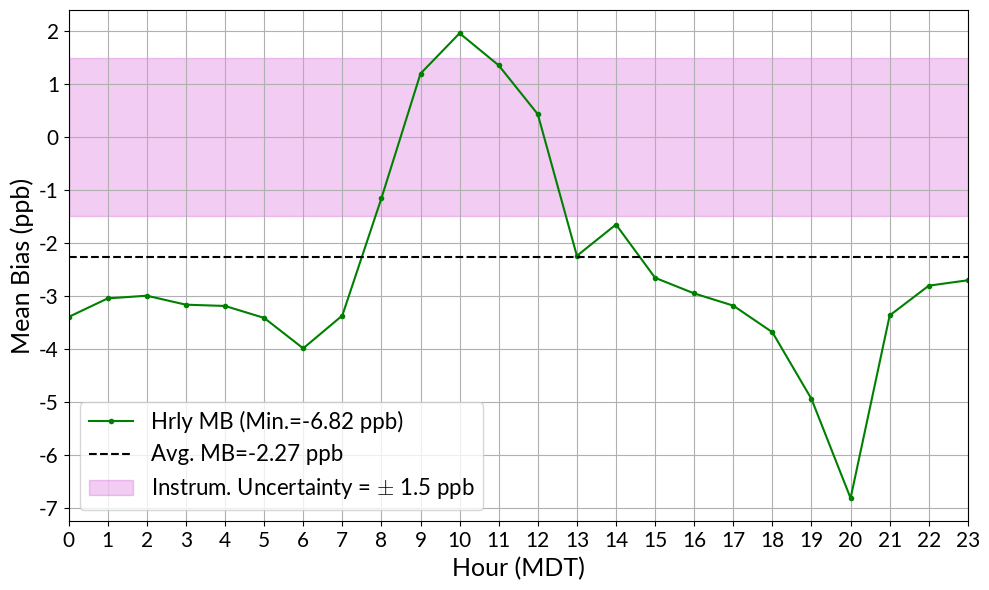

In [10]:
df_o3['hour']=df_o3.index.hour 
hourly_MB = df_o3.groupby('hour').apply(lambda x: (x['model O3'] - x['obs O3']).mean())
print("Hourly Mean Bias (MB):")
print(hourly_MB)
# Plot the hourly Mean Bias and the average over time: 
plt.figure(figsize=(10,6), tight_layout = True)
plt.plot(hourly_MB.index, hourly_MB, color='g', marker='.', label=f"Hrly MB (Min.={np.min(hourly_MB):.2f} ppb)")
plt.plot(hourly_MB.index, np.ones(len(hourly_MB.index))*mb_total, linestyle = 'dashed', color='k',label=f"Avg. MB={mb_total:.2f} ppb")
plt.fill_between(hourly_MB.index, -1.5, 1.5,  color = 'm', alpha = 0.2, label = 'Instrum. Uncertainty = $\pm$ 1.5 ppb')

#plt.ylim([-0.14, 0])
#plt.title('Mean Bias')
plt.ylabel('Mean Bias (ppb)')
plt.xlabel('Hour (MDT)')
plt.xlim([0, 23])
plt.xticks(hour_range)
plt.yticks(np.arange(-7, 3, 1))
plt.grid()
plt.legend()
plt.savefig(dirpath + '/UDAQ_reports/q1_report/plots/hawthorne_udaq_mobilelab_o3_comparison_meanbias.png', dpi =300)
plt.show()

## Mean Normalized Bias

In [12]:
df_o3['O3_diff']= df_o3['model O3']-df_o3['obs O3']
mnb_before_sum = df_o3['O3_diff']/df_o3['obs O3']
mnb_sum_term = np.nansum(mnb_before_sum)
mnb_total= ((1/(len(df_o3['obs O3']))) * mnb_sum_term)
print(mnb_total)

-0.04448223394690315


In [13]:
mnb_before_sum = df_o3['O3_diff']/df_o3['obs O3']
df_mnb_before_sum = pd.DataFrame({'mnb_before_sum':mnb_before_sum})
df_mnb_before_sum['hour']=df_mnb_before_sum.index.hour 
mnb_sum_hrly = df_mnb_before_sum.groupby('hour')['mnb_before_sum'].mean()
print(mnb_sum_hrly)

hour
0    -0.072094
1    -0.069157
2    -0.066882
3    -0.071512
4    -0.080608
5    -0.081438
6    -0.116954
7    -0.108334
8    -0.025210
9     0.039003
10    0.048872
11    0.028963
12    0.007268
13   -0.031584
14   -0.023275
15   -0.036138
16   -0.042287
17   -0.043691
18   -0.054920
19   -0.079288
20   -0.122522
21   -0.068133
22   -0.054287
23   -0.044811
Name: mnb_before_sum, dtype: float64


In [ ]:
# Plot the hourly MNB and the average over time: 
plt.figure(figsize=(10,6), tight_layout = True)
plt.plot(mnb_sum_hrly.index, mnb_sum_hrly*100, color='b', marker='.', label=f"Hrly MNB (Min. ={np.min(mnb_sum_hrly)*100:.2f}%)")
plt.plot(mnb_sum_hrly.index, np.ones(len(mnb_sum_hrly.index))*mnb_total*100, linestyle='dashed', color='k',label=f"Avg. MNB ={mnb_total*100:.2f}%")
plt.fill_between(hourly_MB.index, -2, 2,  color = 'c', alpha = 0.2, label = 'Instrum. Uncertainty = $\pm$2%')
#plt.ylim([-0.12, 0])

plt.ylabel('Mean Normalized Bias (%)')
plt.xlabel('Hour (MDT)')
plt.xlim([0, 23])
plt.ylim([-13, 6])
plt.xticks(hour_range)
plt.yticks(np.arange(-13,6,1))
plt.grid()
plt.legend(loc='upper right')
plt.savefig(dirpath + '/UDAQ_reports/q1_report/plots/hawthorne_udaq_mobilelab_o3_comparison_mean_normalized_bias_percentage.png', dpi =300)
plt.show()

<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_3400211/2906106725.py:6: SyntaxWarning: invalid escape sequence '\p'
  plt.fill_between(hourly_MB.index, -2, 2,  color = 'c', alpha = 0.2, label = 'Instrum. Uncertainty = $\pm$2%')
/tmp/ipykernel_3400211/2906106725.py:6: SyntaxWarning: invalid escape sequence '\p'
  plt.fill_between(hourly_MB.index, -2, 2,  color = 'c', alpha = 0.2, label = 'Instrum. Uncertainty = $\pm$2%')


NameError: name 'np' is not defined

Mean Normalized Bias is a measure of relative error. This figure tells us that overall, UDAQ's Ozone instrument underestimates by about 4.45%, although this varies greatly depending on the hour.

## Counter of how many times UDAQ Ozone is higher than ML Ozone

In [15]:
#Our ML data starts at 12 PM on 7/16 so let's crop out the extra times
new_start_time = pd.Timestamp('2024-07-16 12:00:00')
new_end_time = pd.Timestamp('2024-08-18 18:00:00')
new_index = pd.date_range(start=new_start_time, end=new_end_time, freq='1h')

df_shortened_udaq = df_udaq_o3_load.copy().reindex(new_index)
df_shortened_ml = mobilelab_o3.copy().reindex(new_index)
print(len(df_shortened_udaq['UDAQ O3']))
count_udaq_higher_than_ml = (df_shortened_udaq['UDAQ O3'] > df_shortened_ml['Mobile Lab O3']).sum()
print(count_udaq_higher_than_ml)
percentage_udaq_higher = 100*count_udaq_higher_than_ml/len(df_shortened_udaq['UDAQ O3'])
print(percentage_udaq_higher)

count_udaq_higher_than_ml_and_uncertainty = (df_shortened_udaq['UDAQ O3'] - df_shortened_ml['Mobile Lab O3'] > 1.5).sum()
percentage_udaq_higher_than_ml_and_uncertainty = 100*count_udaq_higher_than_ml_and_uncertainty/len(df_shortened_udaq['UDAQ O3'])
print(percentage_udaq_higher_than_ml_and_uncertainty)

799
178
22.27784730913642
11.013767209011265


In [16]:
# Count NaNs
n_nan_1 = df_shortened_udaq['UDAQ O3'].isna().sum()
n_nan_2 = df_shortened_ml['Mobile Lab O3'].isna().sum()

# Get indices
idx_nan_1 = df_shortened_udaq.index[df_shortened_udaq['UDAQ O3'].isna()].tolist()
idx_nan_2 = df_shortened_ml.index[df_shortened_ml['Mobile Lab O3'].isna()].tolist()

print(f"df1 NaNs: {n_nan_1} at indices {idx_nan_1}")
print(f"df2 NaNs: {n_nan_2} at indices {idx_nan_2}")

df1 NaNs: 5 at indices [Timestamp('2024-07-17 05:00:00'), Timestamp('2024-07-24 05:00:00'), Timestamp('2024-07-31 05:00:00'), Timestamp('2024-08-07 05:00:00'), Timestamp('2024-08-14 05:00:00')]
df2 NaNs: 36 at indices [Timestamp('2024-07-18 14:00:00'), Timestamp('2024-07-18 15:00:00'), Timestamp('2024-07-18 16:00:00'), Timestamp('2024-07-18 17:00:00'), Timestamp('2024-07-22 13:00:00'), Timestamp('2024-07-22 14:00:00'), Timestamp('2024-07-22 15:00:00'), Timestamp('2024-07-22 16:00:00'), Timestamp('2024-07-22 17:00:00'), Timestamp('2024-07-23 13:00:00'), Timestamp('2024-07-23 14:00:00'), Timestamp('2024-07-23 15:00:00'), Timestamp('2024-07-26 11:00:00'), Timestamp('2024-07-26 12:00:00'), Timestamp('2024-07-26 13:00:00'), Timestamp('2024-07-26 14:00:00'), Timestamp('2024-07-28 11:00:00'), Timestamp('2024-07-28 12:00:00'), Timestamp('2024-07-28 13:00:00'), Timestamp('2024-07-28 14:00:00'), Timestamp('2024-07-30 15:00:00'), Timestamp('2024-07-30 16:00:00'), Timestamp('2024-07-30 17:00:00'),

## MDA8 Ozone

In [17]:
df_ozone = pd.DataFrame({
    'UDAQ O3':df_shortened_udaq['UDAQ O3'],
    'ML O3': df_shortened_ml['Mobile Lab O3']
})


# Calculate the 8-hour rolling average
rolling_avg_name_UDAQ = '8hr_rolling_avg_' + 'UDAQ O3'
rolling_avg_name_ML = '8hr_rolling_avg_' + 'ML O3'
df_ozone[rolling_avg_name_UDAQ] = df_ozone['UDAQ O3'].rolling(window=8, min_periods=6).mean()
df_ozone[rolling_avg_name_ML] = df_ozone['ML O3'].rolling(window=8, min_periods=6).mean()
#rolling average only works for 8 hours with no gaps; at least 6 hours

# Calculate the maximum 8-hour average for each day
# Resample to daily frequency, compute the daily max of the rolling averages, drop NA values
daily_max_8hr_avg_ozone_UDAQ = df_ozone[rolling_avg_name_UDAQ].resample('D').max().dropna()
daily_max_8hr_avg_ozone_ML = df_ozone[rolling_avg_name_ML].resample('D').max().dropna()
#print('Max 8 hr avg each day:\n, adjuststart_daily_max_8hr_avg_ozone)

# Map the daily maximum back to the original dataframe
# Create a new temporary column with the daily max 8-hour average for each timestamp
mda8_ozone_name_UDAQ = 'MDA8_O3_' + 'UDAQ O3'
mda8_ozone_name_ML = 'MDA8_O3_' + 'ML O3'
df_ozone[mda8_ozone_name_UDAQ] = df_ozone.index.floor('D').map(daily_max_8hr_avg_ozone_UDAQ)
df_ozone[mda8_ozone_name_ML] = df_ozone.index.floor('D').map(daily_max_8hr_avg_ozone_ML)

#print('Daily max 8 hour avg for each timestamp: \n', df_adjuststart_hourly_ozone['MDA8_O3'])

# # Select daytime values only where MD8A > 70
# df_ozone_day_exceedance_usos = df_ozone[(df_ozone.index.hour >=7) & (df_ozone.index.hour<=20) & (df_ozone['MDA8_O3_USOS O3']>=70)]
# df_ozone_day_exceedance_udaq = df_ozone[(df_ozone.index.hour >=7) & (df_ozone.index.hour<=20) & (df_ozone['MDA8_O3_UDAQ O3']>=70)]
# df_ozone_day_exceedance_filled = df_ozone[(df_ozone.index.hour >=7) & (df_ozone.index.hour<=20) & (df_ozone['MDA8_O3_merged_ozone']>=70)]
#print('When is MDA8 > 70?', df_ozone_day_exceedance)
exceedance_name_UDAQ = 'Exceedance_day_' + 'UDAQ O3'
exceedance_name_ML = 'Exceedance_day_' + 'ML O3'
df_ozone[exceedance_name_UDAQ] = df_ozone[mda8_ozone_name_UDAQ] >= 70
df_ozone[exceedance_name_ML] = df_ozone[mda8_ozone_name_ML] >= 70

In [18]:
display(df_ozone)

,UDAQ O3,ML O3,8hr_rolling_avg_UDAQ O3,8hr_rolling_avg_ML O3,MDA8_O3_UDAQ O3,MDA8_O3_ML O3,Exceedance_day_UDAQ O3,Exceedance_day_ML O3
2024-07-16 12:00:00,73.0,75.766361,NaN,NaN,66.50,74.154005,False,True
2024-07-16 13:00:00,75.0,83.427639,NaN,NaN,66.50,74.154005,False,True
2024-07-16 14:00:00,66.0,76.635722,NaN,NaN,66.50,74.154005,False,True
2024-07-16 15:00:00,62.0,71.467333,NaN,NaN,66.50,74.154005,False,True
2024-07-16 16:00:00,61.0,68.030250,NaN,NaN,66.50,74.154005,False,True
...,...,...,...,...,...,...,...,...
2024-08-18 14:00:00,43.0,43.177662,40.750,39.582055,43.75,43.347904,False,False
2024-08-18 15:00:00,43.0,42.283224,42.875,41.400340,43.75,43.347904,False,False
2024-08-18 16:00:00,40.0,40.946167,43.500,42.658753,43.75,43.347904,False,False
2024-08-18 17:00:00,43.0,41.069806,43.750,43.134187,43.75,43.347904,False,False


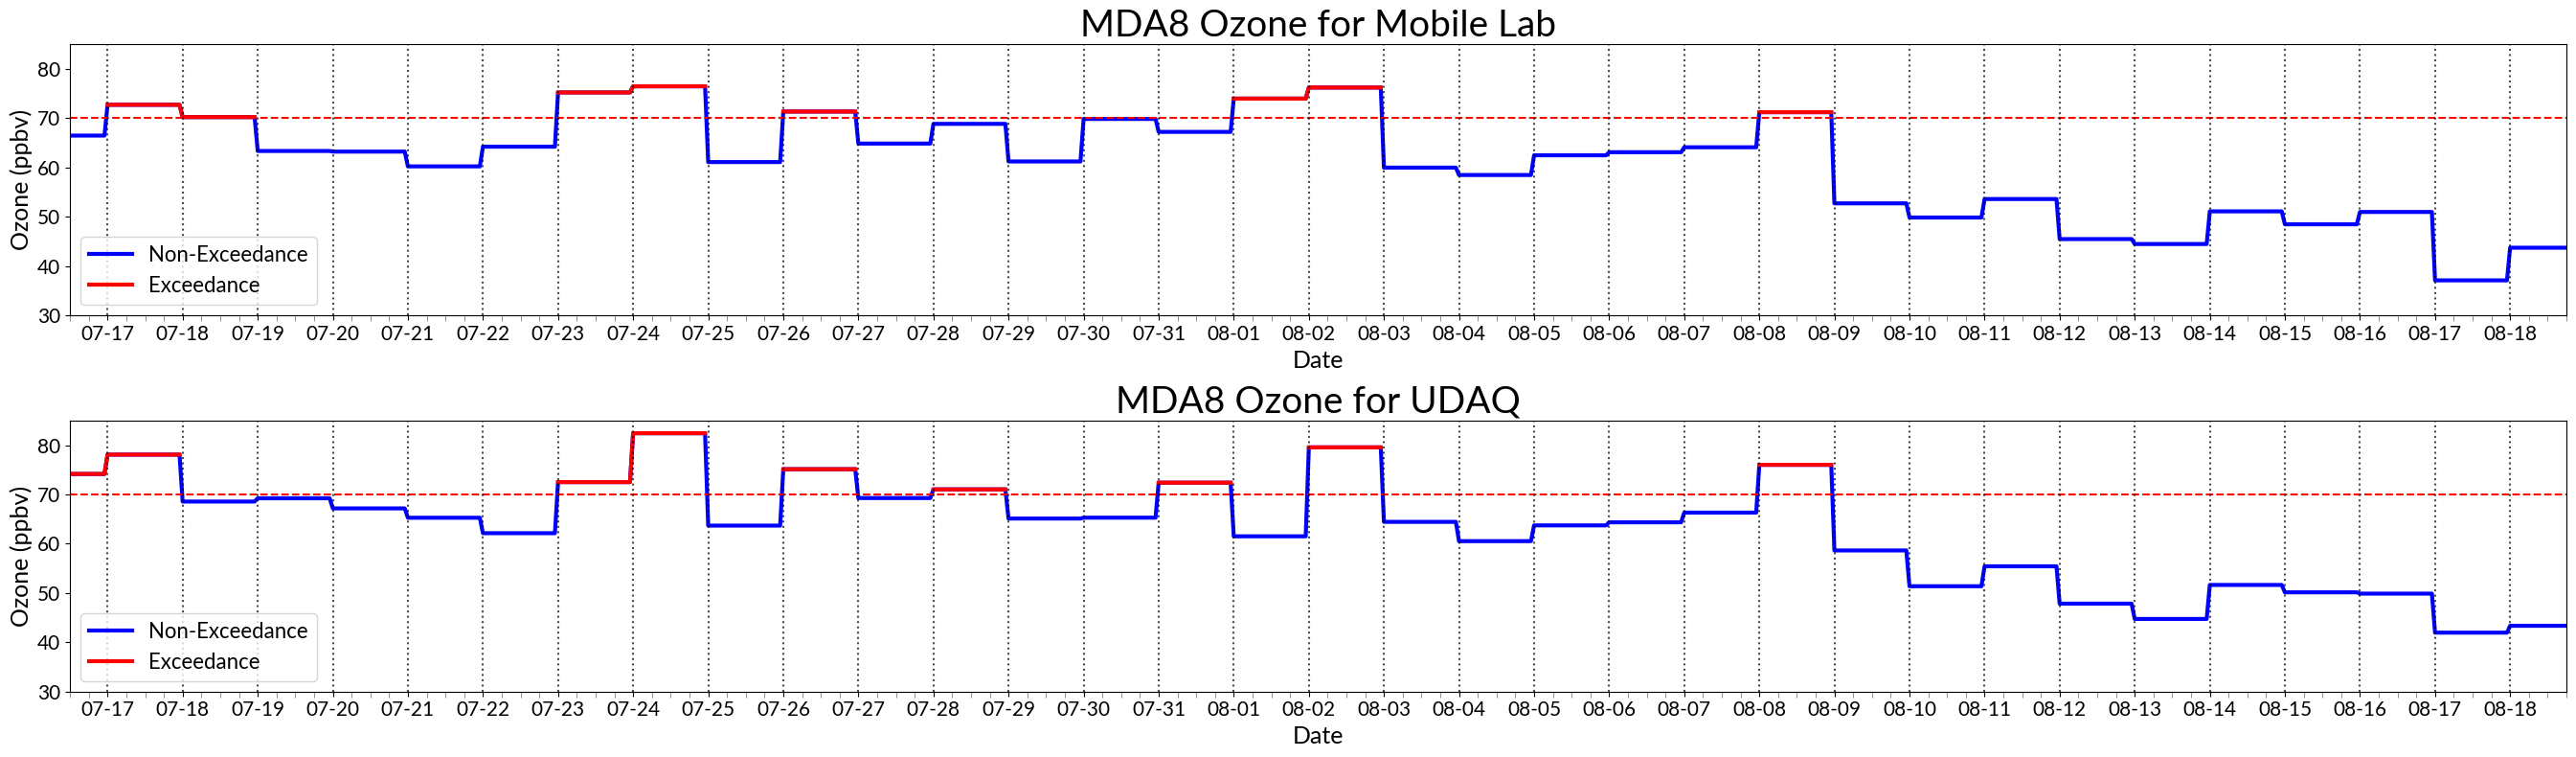

In [42]:
fig, ax = plt.subplots(2,1, figsize = (27,8), tight_layout=True)
threshold = 70

instance_name = ['Mobile Lab', 'UDAQ']
instance_varname = ['UDAQ O3', 'ML O3']
for instance in range(0,2):
    mda8_ozone_name = 'MDA8_O3_' + df_ozone.columns[instance]
    exceedance_name = 'Exceedance_day_' + df_ozone.columns[instance]
    mda8_exceedance = np.where(df_ozone[mda8_ozone_name].values > threshold, df_ozone[mda8_ozone_name].values , np.nan)
    ax[instance].plot(df_ozone.index, df_ozone[mda8_ozone_name], color='b', linewidth = 3, label = 'Non-Exceedance')
    ax[instance].plot(df_ozone.index, mda8_exceedance, color='r', linewidth = 3, label = 'Exceedance')
    ax[instance].margins(x=0)
    ax[instance].set_ylabel('Ozone (ppbv)')
    ax[instance].set_xlabel('Date')
    ax[instance].hlines(y=70, xmin = df_ozone.index[0], xmax = df_ozone.index[len(df_ozone.index)-1], linestyle = 'dashed', color = 'r')
    ax[instance].set_title('MDA8 Ozone for ' + instance_name[instance])

    ax[instance].xaxis.set_major_locator(mdates.DayLocator())
    ax[instance].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

    # Minor ticks: every 6 hours
    ax[instance].xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))

    # Rotate and format tick labels
    ax[instance].tick_params(axis='x', which='major')
    ax[instance].tick_params(axis='x', which='minor', length=4, color='gray')

    ax[instance].set_yticks(np.arange(30,90,10))
    ax[instance].set_ylim([30,85])

    ax[instance].legend(loc='lower left')

    midnight_vals = []
    for midnight_idx in range(12,len(df_ozone.index),24):
        midnight_vals.append(df_ozone.index[midnight_idx])
    for day_pos in midnight_vals:
        ax[instance].axvline(day_pos, color = 'black', linestyle = 'dotted', alpha = 0.7)


[   nan 72.75  70.25     nan    nan    nan    nan 75.25  76.5      nan
 71.375    nan    nan    nan    nan    nan 74.    76.25     nan    nan
    nan    nan    nan 71.25     nan    nan    nan    nan    nan    nan
    nan    nan    nan    nan]


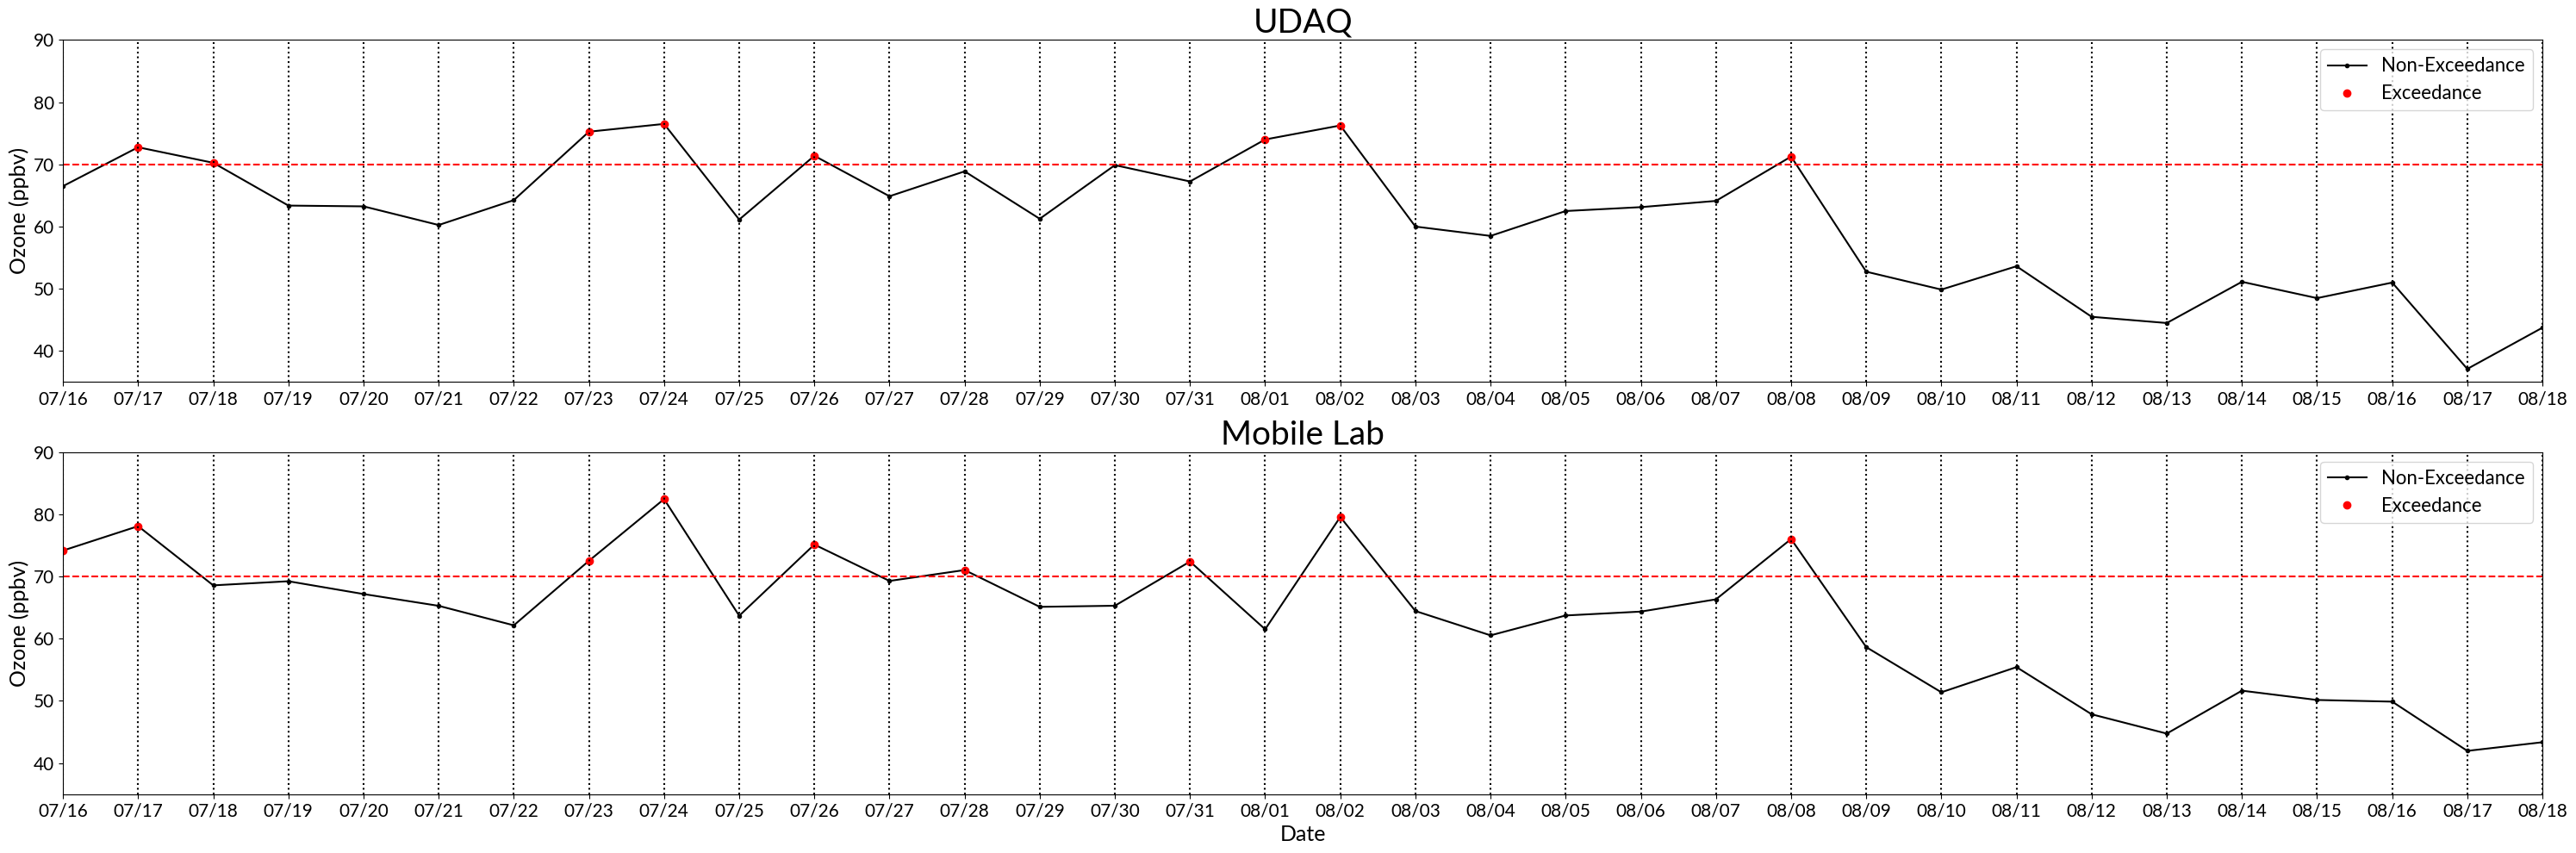

6

In [81]:
fig, ax = plt.subplots(2,1, figsize = (30,10), tight_layout = True)
threshold = 70

ax[0].margins(x=0)
ax[0].plot(daily_max_8hr_avg_ozone_UDAQ.index, daily_max_8hr_avg_ozone_UDAQ, color='k',marker='.', label = 'Non-Exceedance')
# ax[0].plot(df_ozone.index, daily_max_8hr_avg_ozone_UDAQ, color='r', linewidth = 3, label = 'Exceedance')
mda8_exceedance_udaq = np.where(daily_max_8hr_avg_ozone_UDAQ > threshold, daily_max_8hr_avg_ozone_UDAQ, np.nan)
ax[0].plot(daily_max_8hr_avg_ozone_UDAQ.index, mda8_exceedance_udaq, linestyle = '', marker = 'o', color='r', label = 'Exceedance')
print(mda8_exceedance_udaq)

ax[0].set_ylabel('Ozone (ppbv)')

ax[0].hlines(y=70, xmin = daily_max_8hr_avg_ozone_UDAQ.index[0], xmax = daily_max_8hr_avg_ozone_UDAQ.index[len(daily_max_8hr_avg_ozone_UDAQ)-1], color = 'r', linestyle = 'dashed')

ax[0].set_xticks(daily_max_8hr_avg_ozone_UDAQ.index)
ax[0].set_xticklabels(daily_max_8hr_avg_ozone_UDAQ.index.strftime('%m/%d'))
ax[0].set_ylim(35,90)

# midnight_vals_30min = []
# for midnight_idx_30min in range(16,len(df_adjuststart_30min_ozone.index),48):
#     midnight_vals_30min.append(df_adjuststart_30min_ozone.index[midnight_idx_30min])
for day_pos_30min in daily_max_8hr_avg_ozone_UDAQ.index:
    ax[0].axvline(day_pos_30min, color = 'black', linestyle = 'dotted')


lines, labels = ax[0].get_legend_handles_labels()
#lines2, labels2 = ax2.get_legend_handles_labels()
ax[0].legend(lines, labels, loc=0)
ax[0].set_title('UDAQ')


ax[1].margins(x=0)

ax[1].plot(daily_max_8hr_avg_ozone_ML.index, daily_max_8hr_avg_ozone_ML, color='k',marker='.', label = 'Non-Exceedance')
mda8_exceedance_ml = np.where(daily_max_8hr_avg_ozone_ML > threshold, daily_max_8hr_avg_ozone_ML, np.nan)
# ax[1].plot(df_ozone.index, daily_max_8hr_avg_ozone_UDAQ, color='r', linewidth = 3, label = 'Exceedance')
ax[1].plot(daily_max_8hr_avg_ozone_ML.index, mda8_exceedance_ml, linestyle = '', marker='o', color='r', label = 'Exceedance')

ax[1].set_ylabel('Ozone (ppbv)')
ax[1].set_xlabel('Date')

ax[1].hlines(y=70, xmin = daily_max_8hr_avg_ozone_ML.index[0], xmax = daily_max_8hr_avg_ozone_ML.index[len(daily_max_8hr_avg_ozone_ML)-1], color = 'r', linestyle = 'dashed')

ax[1].set_xticks(daily_max_8hr_avg_ozone_ML.index)
ax[1].set_xticklabels(daily_max_8hr_avg_ozone_ML.index.strftime('%m/%d'))
ax[1].set_ylim(35,90)

# midnight_vals_30min = []
# for midnight_idx_30min in range(16,len(df_adjuststart_30min_ozone.index),48):
#     midnight_vals_30min.append(df_adjuststart_30min_ozone.index[midnight_idx_30min])
for day_pos_30min in daily_max_8hr_avg_ozone_ML.index:
    ax[1].axvline(day_pos_30min, color = 'black', linestyle = 'dotted')

lines, labels = ax[1].get_legend_handles_labels()
#lines2, labels2 = ax2.get_legend_handles_labels()
ax[1].legend(lines, labels, loc=0)
ax[1].set_title('Mobile Lab')
plt.savefig(dirpath + '/UDAQ_reports/q1_report/plots/hawthorne_udaq_mobilelab_mda8_exceedances_o3_comparison.png', dpi =300)
plt.show()

6

---

## Average Diurnal

In [20]:
df_shortened_udaq['hour']=df_shortened_udaq.index.hour 
df_shortened_ml['hour']=df_shortened_ml.index.hour 

mean_hrly_ml=df_shortened_ml.groupby('hour')['Mobile Lab O3'].apply(np.nanmean)
mean_hrly_udaq=df_shortened_udaq.groupby('hour')['UDAQ O3'].apply(np.nanmean)

median_hrly_ml=df_shortened_ml.groupby('hour')['Mobile Lab O3'].apply(np.nanmedian)
median_hrly_udaq=df_shortened_udaq.groupby('hour')['UDAQ O3'].apply(np.nanmedian)

std_hrly_ml=df_shortened_ml.groupby('hour')['Mobile Lab O3'].apply(np.nanstd)
std_hrly_udaq=df_shortened_udaq.groupby('hour')['UDAQ O3'].apply(np.nanstd)

#ml_25_percentile = np.percentile(df_shortened_ml['Mobile Lab O3'],25)
ml_percentile_25=df_shortened_ml.groupby('hour')['Mobile Lab O3'].apply(lambda x: np.nanpercentile(x, 25))
ml_percentile_75=df_shortened_ml.groupby('hour')['Mobile Lab O3'].apply(lambda x: np.nanpercentile(x, 75))

udaq_percentile_25=df_shortened_udaq.groupby('hour')['UDAQ O3'].apply(lambda x: np.nanpercentile(x, 25))
udaq_percentile_75=df_shortened_udaq.groupby('hour')['UDAQ O3'].apply(lambda x: np.nanpercentile(x, 75))

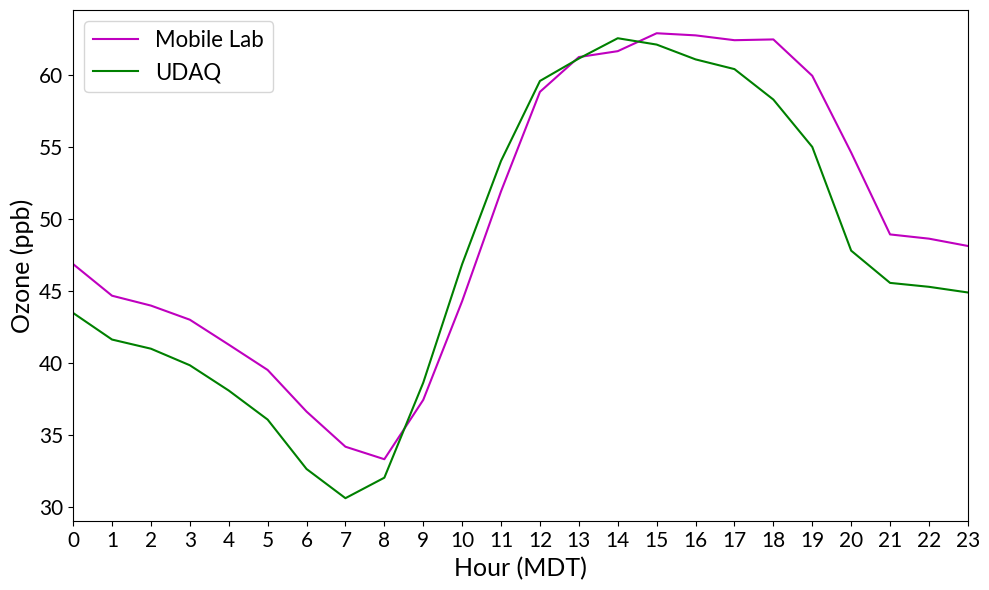

In [ ]:
import matplotlib.lines as mlines

hour_range = np.arange(0,24,1)
plt.figure(figsize=(10,6), tight_layout = True)
ml_plot = plt.plot(hour_range, mean_hrly_ml, '-', label='Mobile Lab', color='m')
udaq_plot = plt.plot(hour_range, mean_hrly_udaq, '-', label=f'UDAQ', color='g')

# plt.fill_between(hour_range, y1 = mean_hrly_udaq-std_udaq, y2 = mean_hrly_udaq+std_udaq,  color = 'g', alpha = 0.4)
# plt.fill_between(hour_range, y1 = mean_hrly_ml-std_ml, y2 = mean_hrly_ml+std_ml, color = 'm', alpha = 0.4)

# Get the current Axes object
ax = plt.gca()

# # Retrieve handles and labels generated by plt.plot
# handles, labels = ax.get_legend_handles_labels()
# handles.append(vline_proxy)
# labels.append(f'Absolute Error, Avg = {mae:.2f} ppb')

plt.margins(x=0)
plt.xlabel('Hour (MDT)')
plt.ylabel('Ozone (ppb)')
#plt.title('Mobile Lab vs. UDAQ Obs \n with Mean Bias and Absolute Error')
plt.xticks(hour_range)
plt.legend()
#plt.grid(True)
plt.savefig(dirpath + '/UDAQ_reports/q1_report/plots/hawthorne_udaq_mobilelab_o3_comparison_hrly_mean.png', dpi =300)
#plt.tight_layout()
plt.show()

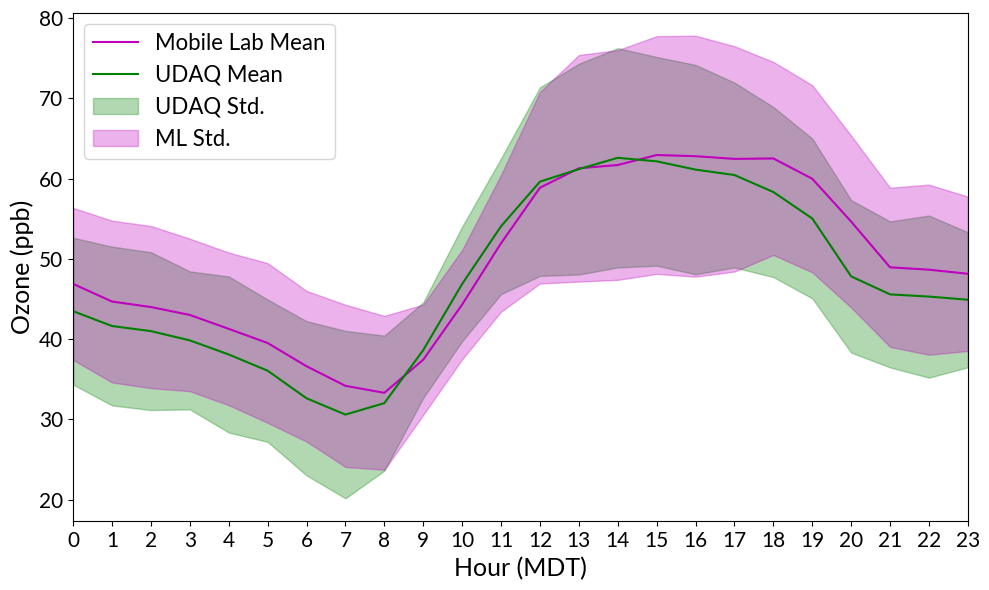

In [36]:
import matplotlib.lines as mlines

hour_range = np.arange(0,24,1)
plt.figure(figsize=(10,6), tight_layout = True)
ml_plot = plt.plot(hour_range, mean_hrly_ml, '-', label='Mobile Lab Mean', color='m')
udaq_plot = plt.plot(hour_range, mean_hrly_udaq, '-', label=f'UDAQ Mean', color='g')

plt.fill_between(hour_range, y1 = mean_hrly_udaq-std_hrly_udaq, y2 = mean_hrly_udaq+std_hrly_udaq, label='UDAQ Std.', color = 'g', alpha = 0.3)
plt.fill_between(hour_range, y1 = mean_hrly_ml-std_hrly_ml, y2 = mean_hrly_ml+std_hrly_ml, label = 'ML Std.', color = 'm', alpha = 0.3)

# Get the current Axes object
ax = plt.gca()

# # Retrieve handles and labels generated by plt.plot
# handles, labels = ax.get_legend_handles_labels()
# handles.append(vline_proxy)
# labels.append(f'Absolute Error, Avg = {mae:.2f} ppb')

plt.margins(x=0)
plt.xlabel('Hour (MDT)')
plt.ylabel('Ozone (ppb)')
#plt.title('Mobile Lab vs. UDAQ Obs \n with Mean Bias and Absolute Error')
plt.xticks(hour_range)
plt.legend()
#plt.grid(True)
plt.savefig(dirpath + '/UDAQ_reports/q1_report/plots/hawthorne_udaq_mobilelab_o3_comparison_hrly_mean_with_std.png', dpi =300)
#plt.tight_layout()
plt.show()

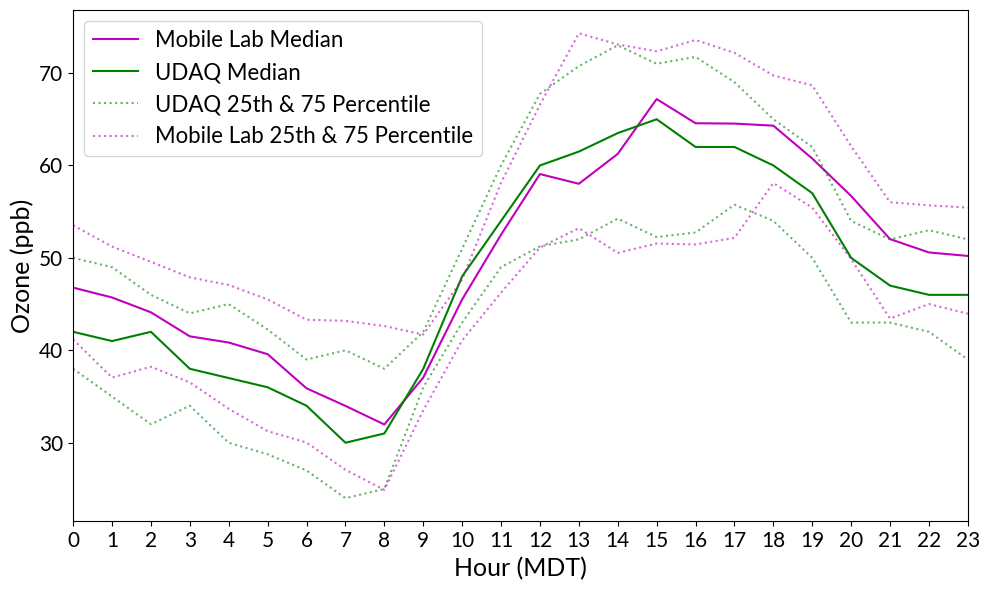

In [ ]:
import matplotlib.lines as mlines


plt.figure(figsize=(10,6), tight_layout = True)
ml_plot = plt.plot(hour_range, median_hrly_ml, '-', label='Mobile Lab Median', color='m')
udaq_plot = plt.plot(hour_range, median_hrly_udaq, '-', label=f'UDAQ Median', color='g')

plt.plot(hour_range, udaq_percentile_25, linestyle = 'dotted', label= 'UDAQ 25th & 75 Percentile',  color = 'g', alpha = 0.6)
plt.plot(hour_range, udaq_percentile_75, linestyle = 'dotted',  color = 'g', alpha = 0.6)

plt.plot(hour_range, ml_percentile_25, linestyle = 'dotted', label= 'Mobile Lab 25th & 75 Percentile',  color = 'm', alpha = 0.6)
plt.plot(hour_range, ml_percentile_75, linestyle = 'dotted',  color = 'm', alpha = 0.6)

# plt.fill_between(hour_range, y1 = udaq_percentile_25, y2 = udaq_percentile_75, label=  color = 'g', alpha = 0.4)
# plt.fill_between(hour_range, y1 = ml_percentile_25, y2 = ml_percentile_75,color = 'm', alpha = 0.4)

# Get the current Axes object
ax = plt.gca()

# # Retrieve handles and labels generated by plt.plot
# handles, labels = ax.get_legend_handles_labels()
# handles.append(vline_proxy)
# labels.append(f'Absolute Error, Avg = {mae:.2f} ppb')

plt.margins(x=0)
plt.xlabel('Hour (MDT)')
plt.ylabel('Ozone (ppb)')
#plt.title('Mobile Lab vs. UDAQ Obs \n with Mean Bias and Absolute Error')
plt.xticks(hour_range)
plt.legend()
#plt.grid(True)
plt.savefig(dirpath + '/UDAQ_reports/q1_report/plots/hawthorne_udaq_mobilelab_o3_comparison_hrly_median_with_percentiles.png', dpi =300)
#plt.tight_layout()
plt.show()